# ASVspoof 2019 LA — Feature × Architecture Experiments
Runs all valid (feature extractor × NN) combos, logs EER + min-tDCF.

| # | Feature | Model |
|---|---------|-------|
| 1–3 | MFCC | CNN / Res2Net / LCNN |
| 4–6 | LFCC | CNN / Res2Net / LCNN |
| 7–9 | CQCC | CNN / Res2Net / LCNN |
| 10–12 | SincConv (learnable front-end) | CNN / Res2Net / LCNN |
| 13 | Raw waveform | RawNet2 |

**Mandatory preprocessing**: resampling, amplitude normalization, fixed-length crop/pad.  
**Optional** (flags in Config): VAD #1, RawBoost #5, reverb #6, denoising #8.

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import librosa
from scipy.fft import dct
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Configuration

In [2]:
LA_ROOT   = '/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA'
TRAIN_DIR = f'{LA_ROOT}/ASVspoof2019_LA_train/flac'
DEV_DIR   = f'{LA_ROOT}/ASVspoof2019_LA_dev/flac'
EVAL_DIR  = f'{LA_ROOT}/ASVspoof2019_LA_eval/flac'
PROTO_DIR = f'{LA_ROOT}/ASVspoof2019_LA_cm_protocols'

SR        = 16000
DURATION  = 4
N_SAMPLES = SR * DURATION
HOP       = 160
WIN       = 400
N_FFT     = 512
N_FRAMES  = N_SAMPLES // HOP

N_MFCC = 60
N_LFCC = 60
N_CQCC = 60
N_SINC = 128

BATCH_SIZE = 32
EPOCHS     = 8
LR         = 1e-4

USE_VAD       = True
USE_RAWBOOST  = True
USE_REVERB    = False
USE_DENOISING = False

CKPT_DIR    = '/kaggle/working/checkpoints'
RESULTS_DIR = '/kaggle/working/results'
for _d in [CKPT_DIR, RESULTS_DIR]:
    os.makedirs(_d, exist_ok=True)
print(f'N_SAMPLES={N_SAMPLES}  N_FRAMES={N_FRAMES}')

N_SAMPLES=64000  N_FRAMES=400


## 2. Dataset Loading

In [3]:
def load_protocol(proto_path, audio_dir):
    rows = []
    with open(proto_path) as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) < 5: continue
            _, fname, _, attack, label = parts
            rows.append({'path': os.path.join(audio_dir, fname + '.flac'),
                         'attack': attack,
                         'label': 0 if label == 'bonafide' else 1})
    return pd.DataFrame(rows)

train_df = load_protocol(f'{PROTO_DIR}/ASVspoof2019.LA.cm.train.trn.txt', TRAIN_DIR)
dev_df   = load_protocol(f'{PROTO_DIR}/ASVspoof2019.LA.cm.dev.trl.txt',   DEV_DIR)
eval_df  = load_protocol(f'{PROTO_DIR}/ASVspoof2019.LA.cm.eval.trl.txt',  EVAL_DIR)

for name, df in [('Train', train_df), ('Dev', dev_df), ('Eval', eval_df)]:
    print(f'{name}: {len(df):>6,}  bonafide={(df.label==0).sum():>5,}  spoof={(df.label==1).sum():>6,}')

Train: 25,380  bonafide=2,580  spoof=22,800
Dev: 24,844  bonafide=2,548  spoof=22,296
Eval: 71,237  bonafide=7,355  spoof=63,882


## 3. Preprocessing

In [4]:
def load_wav(path):
    wav, _ = librosa.load(path, sr=SR, mono=True)
    return wav.astype(np.float32)

def normalize(wav):
    return wav / (np.max(np.abs(wav)) + 1e-8)

def trim_silence(wav, top_db=30):
    t, _ = librosa.effects.trim(wav, top_db=top_db)
    return t if len(t) > SR * 0.1 else wav

def fixed_length(wav, n=N_SAMPLES, train=True):
    if len(wav) < n:
        wav = np.tile(wav, n // len(wav) + 1)
    start = np.random.randint(0, len(wav)-n+1) if train else (len(wav)-n)//2
    return wav[start:start+n]

def rawboost(wav):
    rng = np.random.default_rng()
    snr = rng.uniform(10, 40)
    noise = rng.normal(0, np.sqrt(np.mean(wav**2)/(10**(snr/10))+1e-8), len(wav)).astype(np.float32)
    idx = rng.integers(0, len(wav), max(1, int(0.001*len(wav))))
    noise[idx] += rng.choice([-1,1], len(idx)) * rng.uniform(0.05, 0.3, len(idx))
    return np.clip(wav + noise, -1.0, 1.0)

def reverb(wav):
    decay, delay = np.random.uniform(0.1,0.4), np.random.randint(400,2400)
    out = wav.copy()
    if delay < len(wav):
        out[delay:] += decay * wav[:-delay]
    return np.clip(out, -1.0, 1.0)

def denoise(wav):
    S = librosa.stft(wav, n_fft=N_FFT, hop_length=HOP, win_length=WIN)
    mag, phase = np.abs(S), np.angle(S)
    floor = np.mean(mag[:,:10], axis=1, keepdims=True)
    return librosa.istft(np.maximum(mag-2*floor, 0.1*mag)*np.exp(1j*phase),
                         hop_length=HOP, win_length=WIN, length=len(wav))

def preprocess(path, train=True):
    wav = load_wav(path)
    wav = normalize(wav)
    if USE_VAD:       wav = trim_silence(wav)
    if USE_DENOISING: wav = denoise(wav)
    if train:
        if USE_RAWBOOST and np.random.random() < 0.5: wav = rawboost(wav)
        if USE_REVERB   and np.random.random() < 0.3: wav = reverb(wav)
        wav = normalize(wav)
    return fixed_length(wav, train=train)

## 4. Feature Extraction

In [5]:
def _trim_pad(arr, n=N_FRAMES):
    t = arr.shape[0]
    return arr[:n] if t >= n else np.pad(arr, ((0,n-t),(0,0)))

def feat_mfcc(wav):
    m = librosa.feature.mfcc(y=wav, sr=SR, n_mfcc=N_MFCC,
                              n_fft=N_FFT, hop_length=HOP, win_length=WIN)
    return _trim_pad(m.T).astype(np.float32)

def feat_lfcc(wav, n_filter=70):
    bins = np.linspace(0, SR/2, n_filter+2)
    fq   = np.linspace(0, SR/2, N_FFT//2+1)
    fb   = np.zeros((n_filter, N_FFT//2+1), dtype=np.float32)
    for i in range(n_filter):
        lo,mid,hi = bins[i],bins[i+1],bins[i+2]
        fb[i,(fq>=lo)&(fq<mid)]  = (fq[(fq>=lo)&(fq<mid)]  - lo) /(mid-lo +1e-8)
        fb[i,(fq>=mid)&(fq<=hi)] = (hi-fq[(fq>=mid)&(fq<=hi)])   /(hi -mid+1e-8)
    S    = np.abs(librosa.stft(wav, n_fft=N_FFT, hop_length=HOP, win_length=WIN))**2
    lfcc = dct(np.log(fb@S+1e-8), type=2, axis=0, norm='ortho')[:N_LFCC]
    return _trim_pad(lfcc.T).astype(np.float32)

def feat_cqcc(wav):
    C    = librosa.cqt(wav, sr=SR, fmin=librosa.note_to_hz('C1'),
                       n_bins=96, bins_per_octave=24, hop_length=HOP)
    cqcc = dct(np.log(np.abs(C)**2+1e-8), type=2, axis=0, norm='ortho')[:N_CQCC]
    return _trim_pad(cqcc.T).astype(np.float32)

def feat_raw(wav): return wav.astype(np.float32)

FEATURE_FNS = {'mfcc': feat_mfcc, 'lfcc': feat_lfcc, 'cqcc': feat_cqcc,
               'sincconv': feat_raw, 'raw': feat_raw}

FEAT_SHAPES = {
    'mfcc':     (N_FRAMES, N_MFCC, 1),
    'lfcc':     (N_FRAMES, N_LFCC, 1),
    'cqcc':     (N_FRAMES, N_CQCC, 1),
    'sincconv': (N_SAMPLES, 1),
    'raw':      (N_SAMPLES, 1),
}

# Sanity check
_wav = preprocess(train_df.iloc[0]['path'], train=False)
print('wav:', _wav.shape)
for k, fn in list(FEATURE_FNS.items())[:4]:
    print(f'  {k}: {fn(_wav).shape}')

wav: (64000,)
  mfcc: (400, 60)
  lfcc: (400, 60)
  cqcc: (400, 60)
  sincconv: (64000,)


## 5. Custom Layer — SincConv1D

In [6]:
class SincConv1D(layers.Layer):
    """
    Learnable sinc bandpass filterbank (SincNet-style).
    Input:  (batch, time, 1)
    Output: (batch, time, n_filters)
    """
    def __init__(self, n_filters=128, kernel_size=1025, sample_rate=16000, **kw):
        super().__init__(**kw)
        self.n_filters   = n_filters
        self.kernel_size = kernel_size if kernel_size % 2 == 1 else kernel_size + 1
        self.sample_rate = sample_rate

    def build(self, input_shape):
        hz  = lambda m: 700.0*(10.0**(m/2595.0)-1.0)
        mel = lambda f: 2595.0*np.log10(1.0+f/700.0)
        mp  = np.linspace(mel(30.0), mel(self.sample_rate/2-50), self.n_filters+2)
        hp  = hz(mp)
        self.f1 = self.add_weight(
            name='f1',
            shape=(self.n_filters,),
            trainable=True,
            initializer=tf.constant_initializer(hp[:-2]/self.sample_rate)
        )
        self.f2 = self.add_weight(
            name='f2',
            shape=(self.n_filters,),
            trainable=True,
            initializer=tf.constant_initializer(hp[2:]/self.sample_rate)
        )
        half = self.kernel_size//2
        n    = np.arange(-half, half+1, dtype=np.float32)
        self._n      = tf.constant(n)
        self._window = tf.constant(np.hamming(len(n)).astype(np.float32))
        super().build(input_shape)

    def _lowpass(self, f):
        f = tf.abs(f)[:,tf.newaxis]
        n = self._n[tf.newaxis,:]
        y = tf.math.divide_no_nan(tf.sin(2.0*np.pi*f*n), np.pi*n)
        y = tf.where(tf.abs(n)<1e-6, 2.0*f*tf.ones_like(y), y)
        return y * self._window[tf.newaxis,:]

    def call(self, x):
        f1 = tf.abs(self.f1)
        f2 = tf.abs(self.f2) + f1 + 1e-5
        bp = self._lowpass(f2) - self._lowpass(f1)
        bp = bp / (tf.reduce_max(tf.abs(bp), axis=1, keepdims=True) + 1e-8)
        kernel = tf.transpose(bp)[:,tf.newaxis,:]
        return tf.abs(tf.nn.conv1d(x, kernel, stride=1, padding='SAME'))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'n_filters':self.n_filters,'kernel_size':self.kernel_size,'sample_rate':self.sample_rate})
        return cfg

## 6. Model Definitions

In [7]:
def mfm(x):
    n = tf.shape(x)[-1]//2
    return tf.maximum(x[...,:n], x[...,n:])

def se_block(x, ratio=8):
    c = x.shape[-1]
    s = layers.GlobalAveragePooling2D()(x)
    s = layers.Dense(max(c//ratio,1), activation='relu')(s)
    s = layers.Dense(c, activation='sigmoid')(s)
    return x * layers.Reshape((1,1,c))(s)

def cnn_backbone(x):
    for f in [32,64,128,256]:
        x = layers.Conv2D(f,3,padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(f,3,padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPool2D(2)(x)
        x = layers.Dropout(0.1)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    return layers.Dropout(0.3)(x)

def _r2n_block(x, filters, scale=4):
    g = filters // scale
    x_in = x

    # First 1x1 conv + BN + ReLU
    x = layers.Conv2D(filters, 1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Split into scale groups
    def split_fn(tensor):
        return tf.split(tensor, scale, axis=-1)

    splits = layers.Lambda(split_fn)(x)

    ys = [splits[0]]
    yp = None
    for xi in splits[1:]:
        if yp is not None:
            xi = layers.Add()([xi, yp])
        yi = layers.Conv2D(g, 3, padding='same')(xi)
        yi = layers.BatchNormalization()(yi)
        yi = layers.ReLU()(yi)
        ys.append(yi)
        yp = yi

    # Concatenate and final 1x1
    x = layers.Concatenate(axis=-1)(ys)
    x = layers.Conv2D(filters, 1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = se_block(x)

    # Residual connection
    if x_in.shape[-1] != filters:
        x_in = layers.Conv2D(filters, 1, padding='same')(x_in)
        x_in = layers.BatchNormalization()(x_in)

    x = layers.Add()([x, x_in])
    x = layers.ReLU()(x)

    return x

def res2net_backbone(x):
    x = layers.ReLU()(layers.BatchNormalization()(
            layers.Conv2D(32,7,strides=2,padding='same')(x)))
    x = layers.MaxPool2D(3,strides=2,padding='same')(x)
    for f in [64,128,256]:
        x = _r2n_block(x, f)
        x = layers.MaxPool2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    return layers.Dropout(0.3)(x)

def lcnn_backbone(x):
    for f,k,p in [(64,5,2),(64,1,None),(128,3,2),(128,1,None),(128,3,2)]:
        x = layers.Lambda(mfm)(layers.Conv2D(f*2,k,padding='same')(x))
        x = layers.BatchNormalization()(x)
        if p: x = layers.MaxPool2D(p)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Lambda(mfm)(layers.Dense(256)(x))
    x = layers.Dense(128, activation='relu')(x)
    return layers.Dropout(0.3)(x)

BACKBONE_FNS = {'cnn': cnn_backbone, 'res2net': res2net_backbone, 'lcnn': lcnn_backbone}

In [8]:
def _res1d(x, f, k=3, s=1):
    sc = x
    x = layers.LeakyReLU(0.3)(layers.BatchNormalization()(layers.Conv1D(f,k,strides=s,padding='same')(x)))
    x = layers.BatchNormalization()(layers.Conv1D(f,k,padding='same')(x))
    if sc.shape[-1]!=f or s!=1:
        sc = layers.BatchNormalization()(layers.Conv1D(f,1,strides=s,padding='same')(sc))
    return layers.LeakyReLU(0.3)(layers.Add()([x,sc]))

def build_rawnet2():
    inp = keras.Input(shape=(N_SAMPLES,1))
    x = layers.BatchNormalization()(SincConv1D(N_SINC, 1025)(inp))
    x = layers.MaxPool1D(3)(x)
    for f in [128,128]: x = _res1d(x,f)
    x = layers.MaxPool1D(3)(x)
    for f in [256,256]: x = _res1d(x,f)
    x = layers.MaxPool1D(3)(x)
    for f in [512,512]: x = _res1d(x,f)
    x = layers.MaxPool1D(3)(x)
    x = layers.GRU(1024)(x)
    x = layers.Dropout(0.3)(layers.Dense(1024, activation='relu')(x))
    return Model(inp, layers.Dense(1, activation='sigmoid')(x), name='rawnet2')

def build_model(feature_name, model_name):
    if feature_name == 'raw':
        return build_rawnet2()
    if feature_name == 'sincconv':
        inp = keras.Input(shape=(N_SAMPLES,1))
        x   = SincConv1D(N_SINC, 1025)(inp)
        x   = layers.AveragePooling1D(N_SAMPLES//N_FRAMES, N_SAMPLES//N_FRAMES)(x)
        x   = layers.LayerNormalization()(x)
        x   = layers.Reshape((N_FRAMES, N_SINC, 1))(x)
        x   = BACKBONE_FNS[model_name](x)
        return Model(inp, layers.Dense(1,activation='sigmoid')(x),
                     name=f'sincconv_{model_name}')
    n_c = {'mfcc':N_MFCC,'lfcc':N_LFCC,'cqcc':N_CQCC}[feature_name]
    inp = keras.Input(shape=(N_FRAMES, n_c, 1))
    x   = BACKBONE_FNS[model_name](inp)
    return Model(inp, layers.Dense(1,activation='sigmoid')(x),
                 name=f'{feature_name}_{model_name}')

VALID_COMBOS = [
    ('mfcc','cnn'),('mfcc','res2net'),('mfcc','lcnn'),
    ('lfcc','cnn'),('lfcc','res2net'),('lfcc','lcnn'),
    ('cqcc','cnn'),('cqcc','res2net'),('cqcc','lcnn'),
    ('sincconv','cnn'),('sincconv','res2net'),('sincconv','lcnn'),
    ('raw','rawnet2'),
]
print(f'{len(VALID_COMBOS)} experiments queued')

13 experiments queued


## 7. Data Generator

In [9]:
class ASVDataset(keras.utils.Sequence):
    """
    Keras Sequence that loads, preprocesses and feature-extracts on the fly.
    For 2-D features  → batch shape (B, N_FRAMES, N_COEFFS, 1)
    For raw/sinc      → batch shape (B, N_SAMPLES, 1)
    """
    def __init__(self, df, feature_name, batch_size=32, train=True):
        self.df           = df.reset_index(drop=True)
        self.feature_name = feature_name
        self.batch_size   = batch_size
        self.train        = train
        self.feat_fn      = FEATURE_FNS[feature_name]
        self.raw_input    = feature_name in ('sincconv', 'raw')
        self.indexes      = np.arange(len(df))
        if train:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        idxs = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        xs, ys = [], []
        for i in idxs:
            row  = self.df.iloc[i]
            wav  = preprocess(row['path'], train=self.train)
            feat = self.feat_fn(wav)
            # Add channel dimension
            if self.raw_input:
                feat = feat[:, np.newaxis]          # (N_SAMPLES, 1)
            else:
                feat = feat[..., np.newaxis]        # (N_FRAMES, N_COEFFS, 1)
            xs.append(feat)
            ys.append(row['label'])
        return np.array(xs), np.array(ys, dtype=np.float32)

    def on_epoch_end(self):
        if self.train:
            np.random.shuffle(self.indexes)

## 8. Metrics — EER & min-tDCF

In [10]:
def compute_eer(labels, scores):
    """Returns EER (%) and decision threshold."""
    fpr, tpr, thr = roc_curve(np.array(labels), np.array(scores), pos_label=1)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2 * 100
    return float(eer), float(thr[idx])

def compute_min_tdcf(bonafide_scores, spoof_scores,
                     p_spoof=0.05, c_miss=1.0, c_fa=10.0):
    """
    CM-only normalized min-tDCF.
    Simplified (no ASV system); normalized by cost of trivial all-accept.
    ref: ASVspoof 2019 evaluation plan, Section 8.
    """
    thresholds = np.unique(np.concatenate([bonafide_scores, spoof_scores]))
    best = np.inf
    for thr in thresholds:
        p_miss = float(np.mean(bonafide_scores < thr))
        p_fa   = float(np.mean(spoof_scores   >= thr))
        cost   = c_miss * p_spoof * p_miss + c_fa * (1 - p_spoof) * p_fa
        if cost < best:
            best = cost
    trivial = c_fa * (1 - p_spoof)   # cost when all accepted (miss=0, fa=1)
    return float(best / trivial)

def evaluate_model(model, df, feature_name, batch_size=64):
    """Run inference on df, return (EER%, min-tDCF)."""
    gen    = ASVDataset(df, feature_name, batch_size=batch_size, train=False)
    scores = model.predict(gen, verbose=0).flatten()
    labels = df['label'].values
    eer, _ = compute_eer(labels, scores)
    tdcf   = compute_min_tdcf(scores[labels==0], scores[labels==1])
    return eer, tdcf

## 9. Training Function

In [11]:
import json
import os
import time

def _atomic_write_json(path, data):
    tmp = path + '.tmp'
    with open(tmp, 'w') as f:
        json.dump(data, f)
    os.replace(tmp, path)  # atomic on POSIX filesystems

def train_experiment(feature_name, model_name):
    exp   = f'{feature_name}_{model_name}'
    ckpt  = os.path.join(CKPT_DIR, f'{exp}.weights.h5')
    state_path   = os.path.join(CKPT_DIR, f'{exp}.state.json')
    history_path = os.path.join(CKPT_DIR, f'{exp}.history.json')
    print(f'\n{"="*60}\n  {exp}\n{"="*60}')

    model = build_model(feature_name, model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    model.summary(line_length=90, expand_nested=False)

    train_gen = ASVDataset(train_df, feature_name, BATCH_SIZE, train=True)
    dev_gen   = ASVDataset(dev_df,   feature_name, BATCH_SIZE, train=False)

    # --- Resume from checkpoint if available ---
    initial_epoch = 0
    past_history  = []

    if os.path.isfile(history_path):
        with open(history_path, 'r') as f:
            past_history = json.load(f)

    if os.path.isfile(ckpt) and os.path.isfile(state_path):
        with open(state_path, 'r') as f:
            state = json.load(f)
        initial_epoch = state.get('epoch', 0)
        if initial_epoch >= EPOCHS:
            print(f'Checkpoint already reached target EPOCHS={EPOCHS} (epoch={initial_epoch}). Skipping training.')
        else:
            print(f'Resuming from epoch {initial_epoch} (loading weights from {ckpt})')
        model.load_weights(ckpt)
    elif os.path.isfile(ckpt):
        # Weights exist but no state file. Trust the history file length if present —
        # it's a reliable proxy for epochs actually completed.
        if past_history:
            initial_epoch = len(past_history)
            print(f'Found weights at {ckpt} with no state file, but history has '
                  f'{initial_epoch} epoch(s) logged — resuming from epoch {initial_epoch}.')
        else:
            print(f'Found weights at {ckpt} but no state or history; loading weights, resuming from epoch 0.')
        model.load_weights(ckpt)
        _atomic_write_json(state_path, {'epoch': initial_epoch})  # backfill so this never repeats

    # Persists epoch count AND per-epoch metrics after every epoch, atomically.
    class EpochStateSaver(keras.callbacks.Callback):
        def __init__(self, state_path, history_path, past_history):
            super().__init__()
            self.state_path = state_path
            self.history_path = history_path
            self.history = list(past_history)  # copy, don't mutate the loaded list

        def on_epoch_end(self, epoch, logs=None):
            _atomic_write_json(self.state_path, {'epoch': epoch + 1})
            self.history.append({k: float(v) for k, v in (logs or {}).items()})
            _atomic_write_json(self.history_path, self.history)

    state_saver = EpochStateSaver(state_path, history_path, past_history)

    cbs = [
        ModelCheckpoint(ckpt, save_best_only=True, save_weights_only=True,
                        monitor='val_loss', verbose=0),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                          min_lr=1e-6, verbose=1),
        state_saver,
    ]

    t0 = time.time()
    history = None
    if initial_epoch < EPOCHS:
        history = model.fit(
            train_gen,
            validation_data=dev_gen,
            epochs=EPOCHS,
            initial_epoch=initial_epoch,
            callbacks=cbs,
            verbose=1,
        )
    elapsed = time.time() - t0

    if os.path.isfile(ckpt):
        model.load_weights(ckpt)

    dev_eer,  dev_tdcf  = evaluate_model(model, dev_df,  feature_name)
    eval_eer, eval_tdcf = evaluate_model(model, eval_df, feature_name)
    print(f'Dev   EER={dev_eer:.2f}%  tDCF={dev_tdcf:.4f}')
    print(f'Eval  EER={eval_eer:.2f}%  tDCF={eval_tdcf:.4f}')

    # Plot built from the FULL combined history (every run, every epoch) — never partial.
    full_history = state_saver.history
    if full_history:
        epochs_axis = list(range(1, len(full_history) + 1))
        loss     = [h.get('loss')         for h in full_history]
        val_loss = [h.get('val_loss')     for h in full_history]
        acc      = [h.get('accuracy')     for h in full_history]
        val_acc  = [h.get('val_accuracy') for h in full_history]

        fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3))
        a1.plot(epochs_axis, loss,     label='train')
        a1.plot(epochs_axis, val_loss, label='val')
        a1.set_title(f'{exp} — Loss'); a1.set_xlabel('epoch'); a1.legend()
        a2.plot(epochs_axis, acc,      label='train')
        a2.plot(epochs_axis, val_acc,  label='val')
        a2.set_title(f'{exp} — Accuracy'); a2.set_xlabel('epoch'); a2.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f'{exp}_curve.png'), dpi=100)
        plt.show()

    del model, train_gen, dev_gen
    keras.backend.clear_session()
    import gc; gc.collect()

    return {
        'experiment': exp,
        'feature':    feature_name,
        'model':      model_name,
        'dev_eer':    round(dev_eer,   3),
        'eval_eer':   round(eval_eer,  3),
        'dev_tdcf':   round(dev_tdcf,  4),
        'eval_tdcf':  round(eval_tdcf, 4),
        'train_min':  round(elapsed/60, 1),
        'resumed_from_epoch': initial_epoch,
    }

## 10. Run All Experiments
Iterates every valid (feature, model) combo. Catches exceptions so one failure doesn't abort the run.

Resuming — 11 already done: cqcc_cnn, lfcc_cnn, lfcc_lcnn, lfcc_res2net, mfcc_cnn, mfcc_lcnn, mfcc_res2net, raw_rawnet2, sincconv_cnn, sincconv_lcnn, sincconv_res2net
SKIP mfcc_cnn (already done)
SKIP mfcc_res2net (already done)
SKIP mfcc_lcnn (already done)
SKIP lfcc_cnn (already done)
SKIP lfcc_res2net (already done)
SKIP lfcc_lcnn (already done)
SKIP cqcc_cnn (already done)
SKIP cqcc_res2net (already done)
SKIP cqcc_lcnn (already done)
SKIP sincconv_cnn (already done)
SKIP sincconv_res2net (already done)
SKIP sincconv_lcnn (already done)

  raw_rawnet2


Model: "rawnet2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer) │ (None, 64000, 1)     │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ sinc_conv1d (SincConv1D) │ (None, 64000, 128)   │          256 │ input_layer[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization      │ (None, 64000, 128)   │          512 │ sinc_conv1d[0][0]     │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ max_pooling1d            │ (None, 21333, 128)   │            0 │ batch_normalization[… │
│ (MaxPooling1D)           │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1d (Conv1D)          │ (None, 21333, 128)   │       49,280 │ max_pooling1d[0][0]   │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_1    │ (None, 21333, 128)   │          512 │ conv1d[0][0]          │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ leaky_re_lu (LeakyReLU)  │ (None, 21333, 128)   │            0 │ batch_normalization_… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1d_1 (Conv1D)        │ (None, 21333, 128)   │       49,280 │ leaky_re_lu[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_2    │ (None, 21333, 128)   │          512 │ conv1d_1[0][0]        │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ add (Add)                │ (None, 21333, 128)   │            0 │ batch_normalization_… │
│                          │                      │              │ max_pooling1d[0][0]   │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ leaky_re_lu_1            │ (None, 21333, 128)   │            0 │ add[0][0]             │
│ (LeakyReLU)              │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1d_2 (Conv1D)        │ (None, 21333, 128)   │       49,280 │ leaky_re_lu_1[0][0]   │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_3    │ (None, 21333, 128)   │          512 │ conv1d_2[0][0]        │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ leaky_re_lu_2            │ (None, 21333, 128)   │            0 │ batch_normalization_… │
│ (LeakyReLU)              │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1d_3 (Conv1D)        │ (None, 21333, 128)   │       49,280 │ leaky_re_lu_2[0][0]   │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_4    │ (None, 21333, 128)   │          512 │ conv1d_3[0][0]        │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼─────────────────────

 Total params: 9,598,977 (36.62 MB)

 Trainable params: 9,590,017 (36.58 MB)

 Non-trainable params: 8,960 (35.00 KB)

Checkpoint already reached target EPOCHS=8 (epoch=8). Skipping training.
Dev   EER=9.52%  tDCF=0.0053
Eval  EER=27.86%  tDCF=0.0053


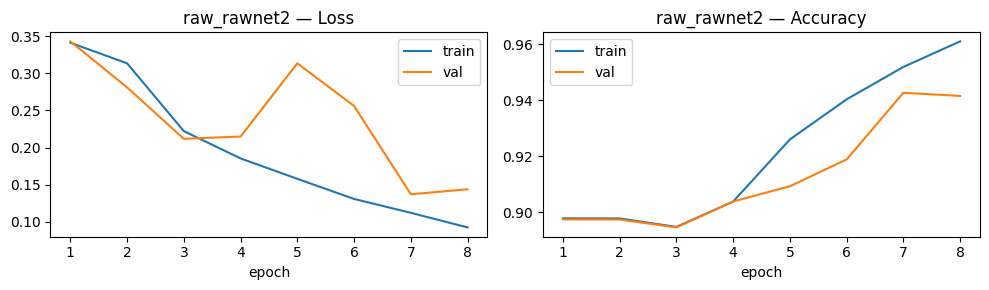


All experiments finished.


In [13]:
import os
import pandas as pd

def _atomic_write_csv(df, path):
    tmp = path + '.tmp'
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)

_partial_csv = os.path.join(RESULTS_DIR, 'results_partial.csv')
if os.path.exists(_partial_csv):
    all_results = pd.read_csv(_partial_csv).to_dict('records')
    _done = {r['experiment'] for r in all_results}
    print(f'Resuming — {len(_done)} already done: {", ".join(sorted(_done))}')
else:
    all_results = []
    _done = set()

for feat, nn in VALID_COMBOS:
    exp = f'{feat}_{nn}'
    if (exp in _done or exp in ["cqcc_res2net", "cqcc_lcnn"]) and exp not in ["raw_rawnet2"]:
        print(f'SKIP {exp} (already done)')
        continue
    try:
        row = train_experiment(feat, nn)
        all_results.append(row)
        _done.add(exp)
    except Exception as exc:
        print(f'ERROR {feat}+{nn}: {exc}')
        all_results.append({
            'experiment': exp, 'feature': feat, 'model': nn,
            'dev_eer': None, 'eval_eer': None,
            'dev_tdcf': None, 'eval_tdcf': None,
            'train_min': None, 'error': str(exc),
        })
    _atomic_write_csv(pd.DataFrame(all_results), _partial_csv)

print('\nAll experiments finished.')

## 11. Results

In [ ]:
results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, 'results_final.csv'), index=False)

# Pretty table
display_cols = ['experiment','dev_eer','eval_eer','dev_tdcf','eval_tdcf','train_min']
print(results_df[display_cols].to_string(index=False))

valid = results_df.dropna(subset=['eval_eer']).copy()
if not valid.empty:
    best = valid.loc[valid['eval_eer'].idxmin()]
    print(f"\nBest (eval EER): {best['experiment']}  "
          f"EER={best['eval_eer']:.2f}%  tDCF={best['eval_tdcf']:.4f}")

In [ ]:
if valid.empty:
    print('No successful experiments to plot.')
else:
    exps = valid['experiment'].tolist()
    x    = np.arange(len(exps))
    w    = 0.35

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(10, len(exps)*0.9), 10))

    ax1.bar(x - w/2, valid['dev_eer'],  w, label='Dev EER (%)',  alpha=0.8)
    ax1.bar(x + w/2, valid['eval_eer'], w, label='Eval EER (%)', alpha=0.8)
    ax1.set_xticks(x); ax1.set_xticklabels(exps, rotation=45, ha='right', fontsize=8)
    ax1.set_ylabel('EER (%) — lower is better')
    ax1.set_title('Equal Error Rate by Experiment')
    ax1.legend()

    ax2.bar(x - w/2, valid['dev_tdcf'],  w, label='Dev min-tDCF',  alpha=0.8)
    ax2.bar(x + w/2, valid['eval_tdcf'], w, label='Eval min-tDCF', alpha=0.8)
    ax2.set_xticks(x); ax2.set_xticklabels(exps, rotation=45, ha='right', fontsize=8)
    ax2.set_ylabel('min-tDCF — lower is better')
    ax2.set_title('Normalized min-tDCF by Experiment')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'results_comparison.png'), dpi=150)
    plt.show()